# Autoencoders

В этом домашнем задании мы даем вам код из скринкастов для простоты работы, а далее можете выполнять задания на основе этого кода и при необходимости писать свой.

In [18]:
from typing import Type, Union

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from IPython.display import clear_output, display
from ipywidgets import Output
from torch import nn, optim
from tqdm.auto import trange

%matplotlib inline

device = "cpu"

In [19]:
class MNISTEncoder(nn.Module):
    def __init__(self, lat_size: int = 10) -> None:
        super().__init__()

        self.lat_size = lat_size

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.lat_size),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)

        return z


class MNISTDecoder(nn.Module):
    def __init__(self, lat_size: int = 10) -> None:
        super().__init__()

        self.lat_size = lat_size

        self.decoder = nn.Sequential(
            nn.Linear(self.lat_size, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        reconstructed_x = self.decoder(z)
        reconstructed_x = reconstructed_x.view(-1, 1, 28, 28)

        return reconstructed_x

In [20]:
class AutoEncoder(nn.Module):
    def __init__(
        self,
        lat_size: int = 10,
        encoder_class: Type[MNISTEncoder] = MNISTEncoder,
        decoder_class: Type[MNISTDecoder] = MNISTDecoder,
        criterion_class: Type[torch.optim.Optimizer] = nn.MSELoss,
    ) -> None:
        super().__init__()

        self.lat_size = lat_size
        self.enc = encoder_class(lat_size)
        self.dec = decoder_class(lat_size)
        self.criterion = criterion_class()

    def encode(self, x):
        return self.enc(x)

    def decode(self, z):
        return self.dec(z)

    def compute_loss(
        self, x: torch.Tensor, return_reconstruction: bool = False
    ) -> Union[tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        z = self.encode(x)
        reconstructed_x = self.decode(z)

        loss = self.criterion(x, reconstructed_x)

        if return_reconstruction:
            return loss, reconstructed_x
        else:
            return loss

In [21]:
def train_epoch(
    model: nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    verbose_num_iters: int = 32,
    device: torch.device = "cuda",
    conditional: bool = False,
) -> list[float]:
    model.to(device)
    model.train()
    epoch_loss_trace = []

    display()
    out = Output()
    display(out)

    for i, batch in enumerate(train_dataloader):
        x, y = batch
        x = x.to(device)

        if conditional:
            y = y.to(device)
            loss, reconstructed_x = model.compute_loss(x, y, return_reconstruction=True)
        else:
            loss, reconstructed_x = model.compute_loss(x, return_reconstruction=True)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        epoch_loss_trace.append(loss.item())

        if (i + 1) % verbose_num_iters == 0:
            with out:
                clear_output(wait=True)

                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1)
                plt.title("Current epoch loss", fontsize=22)
                plt.xlabel("Iteration", fontsize=16)
                plt.ylabel("Reconstruction loss", fontsize=16)
                plt.grid()
                plt.plot(epoch_loss_trace)

                for j in range(3):
                    plt.subplot(2, 6, 4 + j)
                    plt.axis("off")
                    plt.imshow(x[j, 0].cpu().detach().numpy(), cmap="gray")

                    plt.subplot(2, 6, 10 + j)
                    plt.axis("off")
                    plt.imshow(
                        reconstructed_x[j, 0].cpu().detach().numpy(), cmap="gray"
                    )

                plt.show()

    out.clear_output()

    return epoch_loss_trace


def train_model(
    model: nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    num_epochs: int = 5,
    verbose_num_iters: int = 32,
    device: torch.device = "cuda",
    conditional: bool = False,
) -> None:
    loss_trace = []
    for epoch in trange(num_epochs, desc="Epoch: ", leave=True):
        epoch_loss_trace = train_epoch(
            model=model,
            train_dataloader=train_dataloader,
            optimizer=optimizer,
            verbose_num_iters=verbose_num_iters,
            device=device,
            conditional=conditional,
        )

        loss_trace += epoch_loss_trace

    plt.figure(figsize=(10, 5))
    plt.title("Total training loss", fontsize=22)
    plt.xlabel("Iteration", fontsize=16)
    plt.ylabel("Reconstruction loss", fontsize=16)
    plt.grid()
    plt.plot(loss_trace)
    plt.show()

    model.eval()

In [22]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(
    root="./mnist", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./mnist", train=False, download=True, transform=transform
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=256, shuffle=True, num_workers=1
)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=256, shuffle=False, num_workers=1
)

Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

Output()

Epoch:  20%|██        | 1/5 [00:05<00:20,  5.15s/it]

Output()

Epoch:  40%|████      | 2/5 [00:10<00:15,  5.08s/it]

...

Epoch:  60%|██████    | 3/5 [00:15<00:10,  5.20s/it]

Output()

Epoch:  80%|████████  | 4/5 [00:20<00:05,  5.12s/it]

Output()

Epoch: 100%|██████████| 5/5 [00:25<00:00,  5.11s/it]


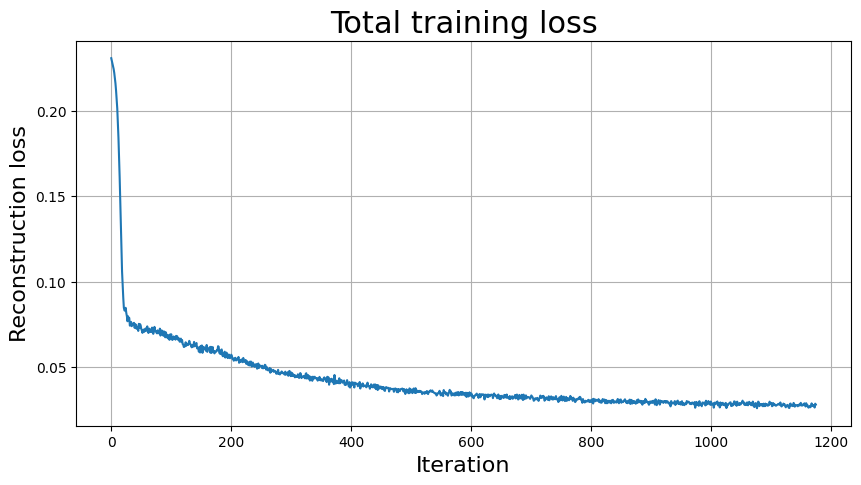

In [23]:
# обучим модель с латентным кодом длины 8
model = AutoEncoder(8)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_model(model, train_dataloader, optimizer, device=device)

Для довольно хорошего сжатия картинок из MNIST'a хватает всего 8 латентных переменных!

На интерполяции видно, как один объект плавно превращается в другой. Стоит заметить, что почти все промежуточные объекты тоже выглядят довольно правдопободно. Иногда такие интерполяции используют для того, чтобы расширить какой-то маленький датасет.

# Часть 1

## Задание 1

Обучите автокодировщик с латентными кодами длины два (остальные гиперпараметры оставьте такими же, как и выше).

Нарисуйте, как и выше, график лосса. Что можно сказать о значении лосса?

Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

Output()

Epoch:  20%|██        | 1/5 [00:05<00:20,  5.06s/it]

Output()

Epoch:  40%|████      | 2/5 [00:10<00:15,  5.10s/it]

...

Epoch:  60%|██████    | 3/5 [00:15<00:10,  5.11s/it]

Output()

Epoch:  80%|████████  | 4/5 [00:20<00:05,  5.14s/it]

Output()

Epoch: 100%|██████████| 5/5 [00:25<00:00,  5.12s/it]


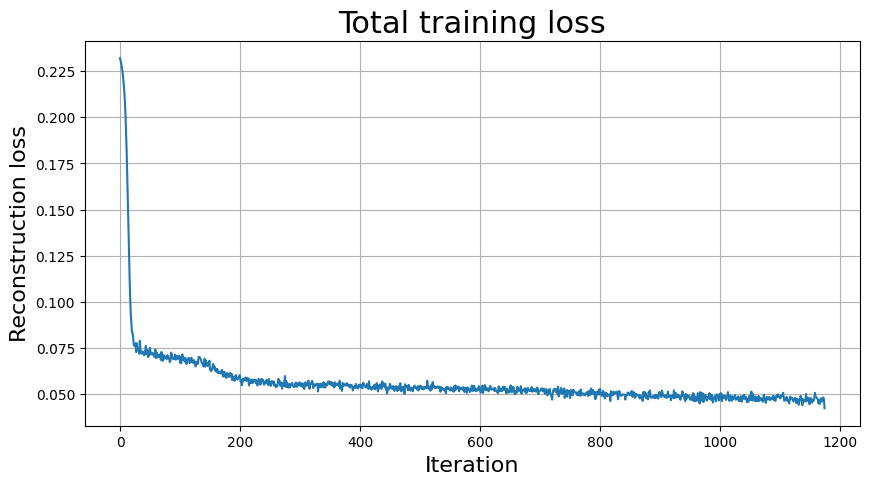

In [24]:
# обучим модель с латентным кодом длины 8
model = AutoEncoder(2)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_model(model, train_dataloader, optimizer, device=device)

## Задание 2

Для 1000 случайных объектов из тренировочной выборки получите их 2d-латентные коды. Нарисуйте эти объекты на плоскости, где координаты - это латентные коды объектов.

Одинаковые цифры (объекты) красьте одним цветом на рисунке.

Какой вывод можно сделать по получившейся визуализации?

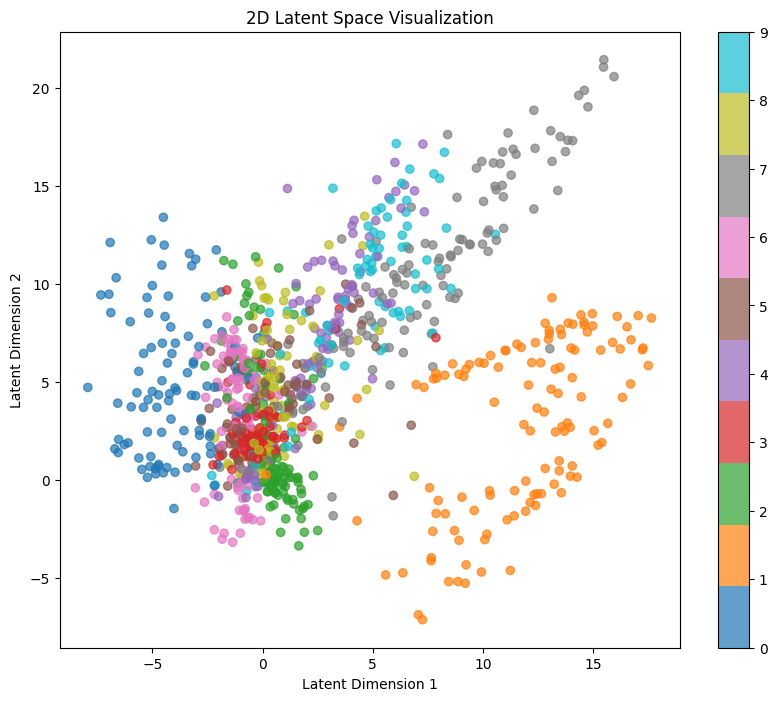

In [26]:
import random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
def get_random_samples(data_loader, num_samples=1000):
    all_samples = []
    all_labels = []
    
    for images, labels in data_loader:
        all_samples.append(images)
        all_labels.append(labels)
    
    # Объединяем все данные в один массив
    all_samples = torch.cat(all_samples)
    all_labels = torch.cat(all_labels)
    
    # Получаем случайные индексы
    random_indices = random.sample(range(len(all_samples)), num_samples)
    
    # Извлекаем случайные объекты
    random_samples = all_samples[random_indices]
    random_labels = all_labels[random_indices]
    
    return random_samples, random_labels

random_images, random_labels = get_random_samples(train_dataloader)
with torch.no_grad():
    latent_codes = model.enc(random_images).numpy()
    

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_codes[:, 0], latent_codes[:, 1], c=random_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title('2D Latent Space Visualization')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.show()


# Часть 2

Автоэнкодеры часто используют для очистки исходных данных от шума. Латентный код сохраняет только главную информацию об объекте, отбрасывая шумовые компоненты.

## Задание 3

Реализуйте функцию, которая обращает 10% пикселей исходного изображения и обучим на такой выборке автокодировщик.

In [28]:
class FlipRandomBits(object):
    def __init__(self, flip_ratio=0.1):
        self.flip_ratio = flip_ratio

    def __call__(self, x):
        # ваш код здесь

        return x


transform = transforms.Compose([transforms.ToTensor(), FlipRandomBits()])

train_dataset_with_noise = torchvision.datasets.MNIST(
    root="./mnist", train=True, download=True, transform=transform
)
train_dataloader_with_noise = torch.utils.data.DataLoader(
    train_dataset_with_noise, batch_size=256, shuffle=True, num_workers=1
)

## Задание 4

Нарисуйте 10 случайных зашумленных на 10% изображений. Что можно сказать об этих изображениях?

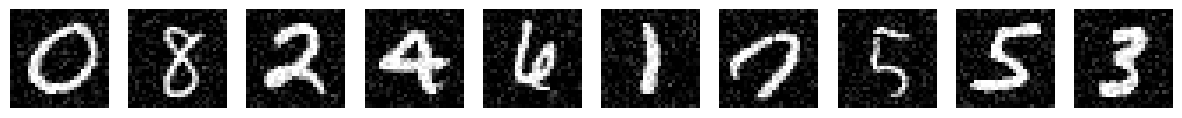

In [30]:
def add_noise(images, noise_factor=0.1):
    noisy_images = images + noise_factor * torch.randn_like(images)
    noisy_images = torch.clip(noisy_images, 0., 1.)
    return noisy_images

indices = torch.randperm(len(train_dataset_with_noise))[:10]
random_images = torch.stack([train_dataset_with_noise[i][0] for i in indices])

noisy_images = add_noise(random_images)
fig, axes = plt.subplots(1, 10, figsize=(15, 1.5))
for i, ax in enumerate(axes):
    ax.imshow(noisy_images[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.show()

## Задание 5

Обучите автокодировщик с латентным кодом длины 64 на зашумленных данных. Выведите на экран график лосса. Сравните этот лосс с лоссом автокодировщика из скринкаста.

Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

Output()

Epoch:  20%|██        | 1/5 [00:05<00:20,  5.03s/it]

Output()

Epoch:  40%|████      | 2/5 [00:10<00:15,  5.08s/it]

...

Epoch:  60%|██████    | 3/5 [00:15<00:10,  5.10s/it]

Output()

Epoch:  80%|████████  | 4/5 [00:20<00:05,  5.13s/it]

Output()

Epoch: 100%|██████████| 5/5 [00:25<00:00,  5.12s/it]


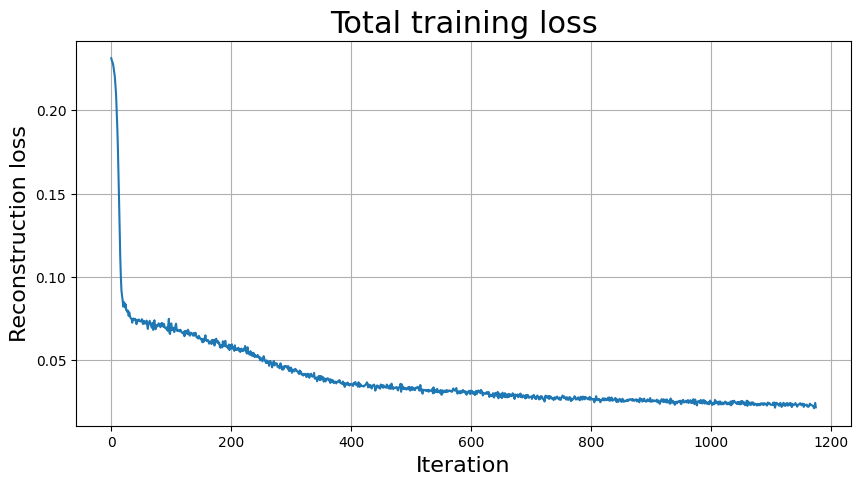

In [31]:
model = AutoEncoder(64)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_model(model, train_dataloader_with_noise, optimizer, device=device)

## Задание 6

Для 10 случайных изображений нарисуйте рядом исходное (зашумленное) и восстановленное изображения. Что можно сказать про эти картинки?

In [ ]:
# ваш код здесь

# Часть 3

Теперь поработаем с VAE. В этом задании Вам необходимо модифицировать классы для VAE так, чтобы он решал задачу условной генерации. То есть теперь мы хотим научить VAE генерировать не просто цифру, а заданную ему на вход цифру.

## Задание 7

Допишите функцию forward:
* onehot_y - метка y, переведенная в вектор из нулей длины 10, где на i-м месте стоит 1 (i - кодируемая цифра). Вам пригодится `nn.functional.one_hot`
* z - сконкатенируйте латентный код z и onehot_y и сохраните результат в переменную z

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class MNISTEncoder_cvae(nn.Module):
    def __init__(self, lat_size):
        super().__init__()

        self.lat_size = lat_size

        self.flatten = nn.Flatten()
        self.enc_net = nn.Sequential(nn.Linear(794, 512), nn.ReLU())

        self.mu = nn.Linear(512, self.lat_size)
        self.log_sigma = nn.Linear(512, self.lat_size)

    def forward(
        self, 
        x: torch.Tensor,
        y: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.flatten(x)

        onehot_t = F.one_hot(y, num_classes=10).float()
        z = torch.cat((z, onehot_t), dim=1)
        z = self.enc_net(z)
        mu = self.mu(z)
        log_sigma = self.log_sigma(z)

        return mu, log_sigma


class MNISTDecoder_cvae(nn.Module):
    def __init__(self, lat_size: int) -> None:
        super().__init__()

        self.lat_size = lat_size

        self.dec_net = nn.Sequential(
            nn.Linear(self.lat_size + 10, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),
        )

    def forward(self,
                z: torch.Tensor, 
                y: torch.Tensor) -> torch.Tensor:
        
        onehot_y = F.one_hot(y, num_classes=10).float()
        z_cond = torch.cat((z, onehot_y), dim=1)

        x_reconstructed = self.dec_net(z_cond)
        x_reconstructed = x_reconstructed.view(-1, 1, 28, 28)

        return x_reconstructed

In [33]:
class ConditionalVariationalAutoEncoder(nn.Module):
    def __init__(
        self,
        lat_size: int,
        KL_weight: float = 0.001,
        encoder_class: Type[MNISTEncoder_cvae] = MNISTEncoder_cvae,
        decoder_class: Type[MNISTDecoder_cvae] = MNISTDecoder_cvae,
        criterion_class: Type[nn.MSELoss] = nn.MSELoss,
    ) -> None:
        super().__init__()

        self.lat_size = lat_size
        self.enc = encoder_class(lat_size)
        self.dec = decoder_class(lat_size)

        self.criterion = criterion_class()

        self.k = 0
        self.KL_weight = KL_weight

    def encode(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.enc(x, y)

    def decode(self, z: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.dec(z, y)

    def sample_z(self, mu: torch.Tensor, log_sigma: torch.Tensor) -> torch.Tensor:
        eps = torch.randn(mu.size()).to(mu.device)

        return mu + torch.exp(log_sigma / 2) * eps

    def custom_loss(
        self,
        x: torch.Tensor,
        reconstructed_x: torch.Tensor,
        mu: torch.Tensor,
        log_sigma: torch.Tensor,
    ) -> torch.Tensor:
        KL = torch.mean(
            -0.5 * torch.sum(1 + log_sigma - mu**2 - log_sigma.exp(), dim=1), dim=0
        )
        reconstruction_loss = self.criterion(x, reconstructed_x)

        return KL * self.KL_weight + reconstruction_loss

    def compute_loss(
        self, x: torch.Tensor,
        y: torch.Tensor, return_reconstruction: bool = False
    ) -> Union[tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        mu, log_sigma = self.encode(x, y)
        z = self.sample_z(mu, log_sigma)
        reconstructed_x = self.decode(z, y)

        loss = self.custom_loss(x, reconstructed_x, mu, log_sigma)

        if return_reconstruction:
            return loss, reconstructed_x
        else:
            return loss

In [35]:
def train_epoch_custom(
    model: nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    verbose_num_iters: int = 32,
    device: torch.device = "cuda",
    conditional: bool = False,
) -> list[float]:
    model.to(device)
    model.train()
    epoch_loss_trace = []

    display()
    out = Output()
    display(out)

    for i, batch in enumerate(train_dataloader):
        x, y = batch
        x = x.to(device)

        if conditional:
            y = y.to(device)
            loss, reconstructed_x = model.compute_loss(x, y, return_reconstruction=True)
        else:
            loss, reconstructed_x = model.compute_loss(x,y, return_reconstruction=True)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        epoch_loss_trace.append(loss.item())

        if (i + 1) % verbose_num_iters == 0:
            with out:
                clear_output(wait=True)

                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1)
                plt.title("Current epoch loss", fontsize=22)
                plt.xlabel("Iteration", fontsize=16)
                plt.ylabel("Reconstruction loss", fontsize=16)
                plt.grid()
                plt.plot(epoch_loss_trace)

                for j in range(3):
                    plt.subplot(2, 6, 4 + j)
                    plt.axis("off")
                    plt.imshow(x[j, 0].cpu().detach().numpy(), cmap="gray")

                    plt.subplot(2, 6, 10 + j)
                    plt.axis("off")
                    plt.imshow(
                        reconstructed_x[j, 0].cpu().detach().numpy(), cmap="gray"
                    )

                plt.show()

    out.clear_output()

    return epoch_loss_trace

In [36]:
def train_model_custom(
    model: nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    num_epochs: int = 5,
    verbose_num_iters: int = 32,
    device: torch.device = "cuda",
    conditional: bool = False,
) -> None:
    loss_trace = []
    for epoch in trange(num_epochs, desc="Epoch: ", leave=True):
        epoch_loss_trace = train_epoch_custom(
            model=model,
            train_dataloader=train_dataloader,
            optimizer=optimizer,
            verbose_num_iters=verbose_num_iters,
            device=device,
            conditional=conditional,
        )

        loss_trace += epoch_loss_trace

    plt.figure(figsize=(10, 5))
    plt.title("Total training loss", fontsize=22)
    plt.xlabel("Iteration", fontsize=16)
    plt.ylabel("Reconstruction loss", fontsize=16)
    plt.grid()
    plt.plot(loss_trace)
    plt.show()

    model.eval()

## Задание 8

Обучите Conditional VAE с `hidden_dim = 2`. Остальные гиперпараметры оставьте как в скринкасте.

Чему равен loss в конце обучения?

Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

Output()

Epoch:  20%|██        | 1/5 [00:05<00:23,  5.79s/it]

Output()

Epoch:  40%|████      | 2/5 [00:11<00:17,  5.79s/it]

...

Epoch:  60%|██████    | 3/5 [00:17<00:11,  5.77s/it]

Output()

Epoch:  80%|████████  | 4/5 [00:23<00:05,  5.80s/it]

Output()

Epoch: 100%|██████████| 5/5 [00:28<00:00,  5.80s/it]


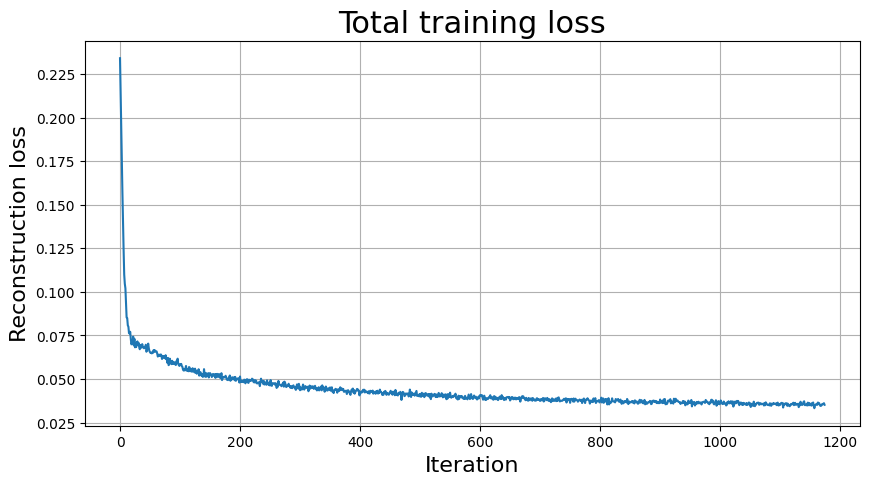

In [37]:
model = ConditionalVariationalAutoEncoder(64)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_model_custom(model, train_dataloader_with_noise, optimizer, device=device)

In [52]:
z = torch.randn(1, latent_dim).to(torch.int64)
print(z)
print(z.shape)

num_classes=10

a=torch.eye(num_classes)[i].unsqueeze(0).to(torch.int64)
print(a)
print(a.shape)

tensor([[ 2,  1,  0, -1,  0,  1,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  1,  1,  1,  0,  0,  1,
          0, -1,  0,  0,  0, -1,  0,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0, -2,
          0,  0,  0,  1,  0,  0,  0,  0, -1,  0]])
torch.Size([1, 64])
tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
torch.Size([1, 10])


## Задание 9

С помощью обученного Conditional VAE сгенерируйте цифры 0, 1, 2, ..., 9 из случайных латентных кодов с условием на заданную цифру.

Визуализируйте результат. Что можно сказать о полученных изображениях?

In [49]:
num_classes=10
latent_dim=64
model.eval()
with torch.no_grad():
    for i in range(10):
        z = torch.randn(1, latent_dim).to(torch.int64)
        c = torch.eye(num_classes)[i].unsqueeze(0).to(torch.int64)
        sample = model.decode(z, c).cpu()
        plt.imshow(sample.view(28, 28), cmap='gray')
        plt.title(f'Generated digit: {i}')
        plt.show()

RuntimeError: Tensors must have same number of dimensions: got 2 and 3